# Master Model Ladder Benchmark & Range Forecast Suite (`M01AB`)

This notebook consolidates holdout test predictions across all individual models on the **2019 Test Set (281 days)**:
1. **Point Forecast Benchmark Table (Models 0–8)**: Evaluated strictly by point accuracy metrics (RMSLE, RMSE, MAE, WAPE).
2. **Probabilistic Range Deliverable (Model 9)**: Evaluated by Inventory Service Level (%) and Demand Uncertainty Band Width ($[P_{10}, P_{90}]$).


In [1]:
import os
import sys
import warnings
import subprocess

# Auto-Dependency Guard: Check and install missing packages dynamically
pkg_map = {
    'prophet': 'prophet',
    'statsmodels': 'statsmodels',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
    'shap': 'shap',
    'torch': 'torch',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn'
}

missing = []
for mod_name, pip_name in pkg_map.items():
    try:
        __import__(mod_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Installing missing dependencies: {missing}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
        print("Dependencies successfully installed!")
    except Exception as err:
        print(f"Warning: Auto-pip install notice ({err}). Proceeding with environment packages...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

TARGET_DRUG = 'M01AB'

# Dynamic Dataset Path Finder
dataset_candidates = ['../dataset', 'dataset', '../../dataset', '../times_series/dataset', 'times_series/dataset']
data_dir = None
for cand in dataset_candidates:
    if os.path.exists(os.path.join(cand, 'train_daily.csv')):
        data_dir = cand
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate train_daily.csv dataset")

train_df = pd.read_csv(os.path.join(data_dir, 'train_daily.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'val_daily.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_daily.csv'))

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])

train_series = train_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
val_series = val_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
test_series = test_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')

combined_series = pd.concat([train_series, val_series]).asfreq('D')
full_series = pd.concat([combined_series, test_series]).asfreq('D')

def evaluate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.clip(np.array(y_pred), 0, None)
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    return {'RMSLE': rmsle, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'WAPE (%)': wape}

print(f"Dataset Partitioning for {TARGET_DRUG}:")
print(f"  * Train (2014-2017): {len(train_series):,} days")
print(f"  * Val   (2018):      {len(val_series):,} days")
print(f"  * Test  (2019):      {len(test_series):,} days")


Dataset Partitioning for M01AB:
  * Train (2014-2017): 1,460 days
  * Val   (2018):      365 days
  * Test  (2019):      281 days


In [ ]:
# Load all saved model predictions
m0_df = pd.read_csv('m0_naive_preds.csv')
m1_df = pd.read_csv('m1_arima_preds.csv')
m2_df = pd.read_csv('m2_ets_preds.csv')
m3a_df = pd.read_csv('m3_sarima_preds.csv')
m3b_df = pd.read_csv('m3_sarimax_preds.csv')
m4_df = pd.read_csv('m4_prophet_preds.csv')
m5_df = pd.read_csv('m5_lstm_preds.csv')
m6_df = pd.read_csv('m6_lightgbm_preds.csv')
m7_df = pd.read_csv('m7_xgb_quantile_preds.csv')
m8_df = pd.read_csv('m8_tft_preds.csv')
hybrid_df = pd.read_csv('m01ab_hybrid_supply_chain_plan.csv')

point_preds = {
    'Model 0: Naive Baseline (k*=365)': m0_df['pred_Naive_raw'].values if 'pred_Naive_raw' in m0_df else m0_df['pred_Naive'].values,
    'Model 1: ARIMA': m1_df['pred_ARIMA'].values,
    'Model 2: Holt-Winters ETS': m2_df['pred_ETS'].values,
    'Model 3a: Pure SARIMA': m3a_df['pred_SARIMA'].values,
    'Model 3b: SARIMAX + Exog': m3b_df['pred_SARIMAX'].values,
    'Model 4: Prophet': m4_df['pred_Prophet'].values,
    'Model 5: PyTorch LSTM': m5_df['pred_LSTM'].values,
    'Model 6: LightGBM + SHAP (Optuna Champion)': m6_df['pred_LightGBM'].values,
    'Model 7: XGBoost Quantile (P50 Median)': m7_df['pred_XGB_Quantile'].values,
    'Model 8: TFT / Deep Attention': m8_df['pred_TFT'].values
}

bench_results = []
for name, preds in point_preds.items():
    met = evaluate_metrics(test_series, preds)
    met['Model'] = name
    bench_results.append(met)

bench_df = pd.DataFrame(bench_results).sort_values('RMSLE').reset_index(drop=True)
print("=" * 80)
print(f"  PART A: POINT FORECAST BENCHMARK TABLE — DRUG: {TARGET_DRUG} (TEST 2019)")
print("=" * 80)
display(bench_df[['Model', 'RMSLE', 'RMSE', 'MAE', 'WAPE (%)']])


  PART A: POINT FORECAST BENCHMARK TABLE — DRUG: M01AB (TEST 2019)


,Model,RMSLE,RMSE,MAE,WAPE (%)
0,Model 6: LightGBM + SHAP (Optuna Champion),0.501386,2.975184,2.292746,42.461895
1,Model 7: XGBoost Quantile (P50 Median),0.505219,2.945626,2.254044,41.745134
2,Model 4: Prophet,0.508671,2.830919,2.197120,40.690885
3,Model 2: Holt-Winters ETS,0.509075,2.825178,2.192837,40.611571
4,Model 3b: SARIMAX + Exog,0.509116,3.010686,2.306167,42.710452
5,Model 1: ARIMA,0.516449,3.065547,2.322834,43.019123
6,Model 3a: Pure SARIMA,0.516509,3.062990,2.320793,42.981335
7,Model 5: PyTorch LSTM,0.526571,2.860841,2.232149,41.339628
8,Model 8: TFT / Deep Attention,0.569652,3.325139,2.496723,46.239575
9,Model 0: Naive Baseline (k*=365),0.679815,3.862810,2.900961,53.726100


In [3]:
# Display Part B: Probabilistic Demand Range Deliverable (Model 9)
print("=" * 80)
print(f"  PART B: PROBABILISTIC DEMAND RANGE DELIVERABLE [P10, P50, P90] — MODEL 9")
print("=" * 80)
display(hybrid_df.head(15))


  PART B: PROBABILISTIC DEMAND RANGE DELIVERABLE [P10, P50, P90] — MODEL 9


,Date,Drug Category,Actual Sales,Lean Lower Bound (P10),Expected Demand Anchor (P50),Upper Target Stock (P90),Uncertainty Band Width (P90 - P10),Order Range (Lean P10 Pack Target),Order Range (Expected P50 Pack Target),Order Range (Safety P90 Pack Target)
0,2019-01-01,M01AB,0.00,0.77,1.78,11.78,11.01,1,2,12
1,2019-01-02,M01AB,5.33,0.65,1.78,13.24,12.59,1,2,14
2,2019-01-03,M01AB,4.33,2.90,4.31,14.75,11.85,3,5,15
3,2019-01-04,M01AB,7.00,3.39,4.50,14.81,11.42,4,5,15
4,2019-01-05,M01AB,8.01,3.48,4.80,12.90,9.42,4,5,13
5,2019-01-06,M01AB,8.33,3.28,3.97,12.45,9.17,4,4,13
6,2019-01-07,M01AB,0.00,0.92,2.18,11.14,10.22,1,3,12
7,2019-01-08,M01AB,4.34,2.82,4.38,14.57,11.75,3,5,15
8,2019-01-09,M01AB,3.00,2.87,4.39,13.07,10.20,3,5,14
9,2019-01-10,M01AB,8.00,2.88,4.79,13.78,10.90,3,5,14


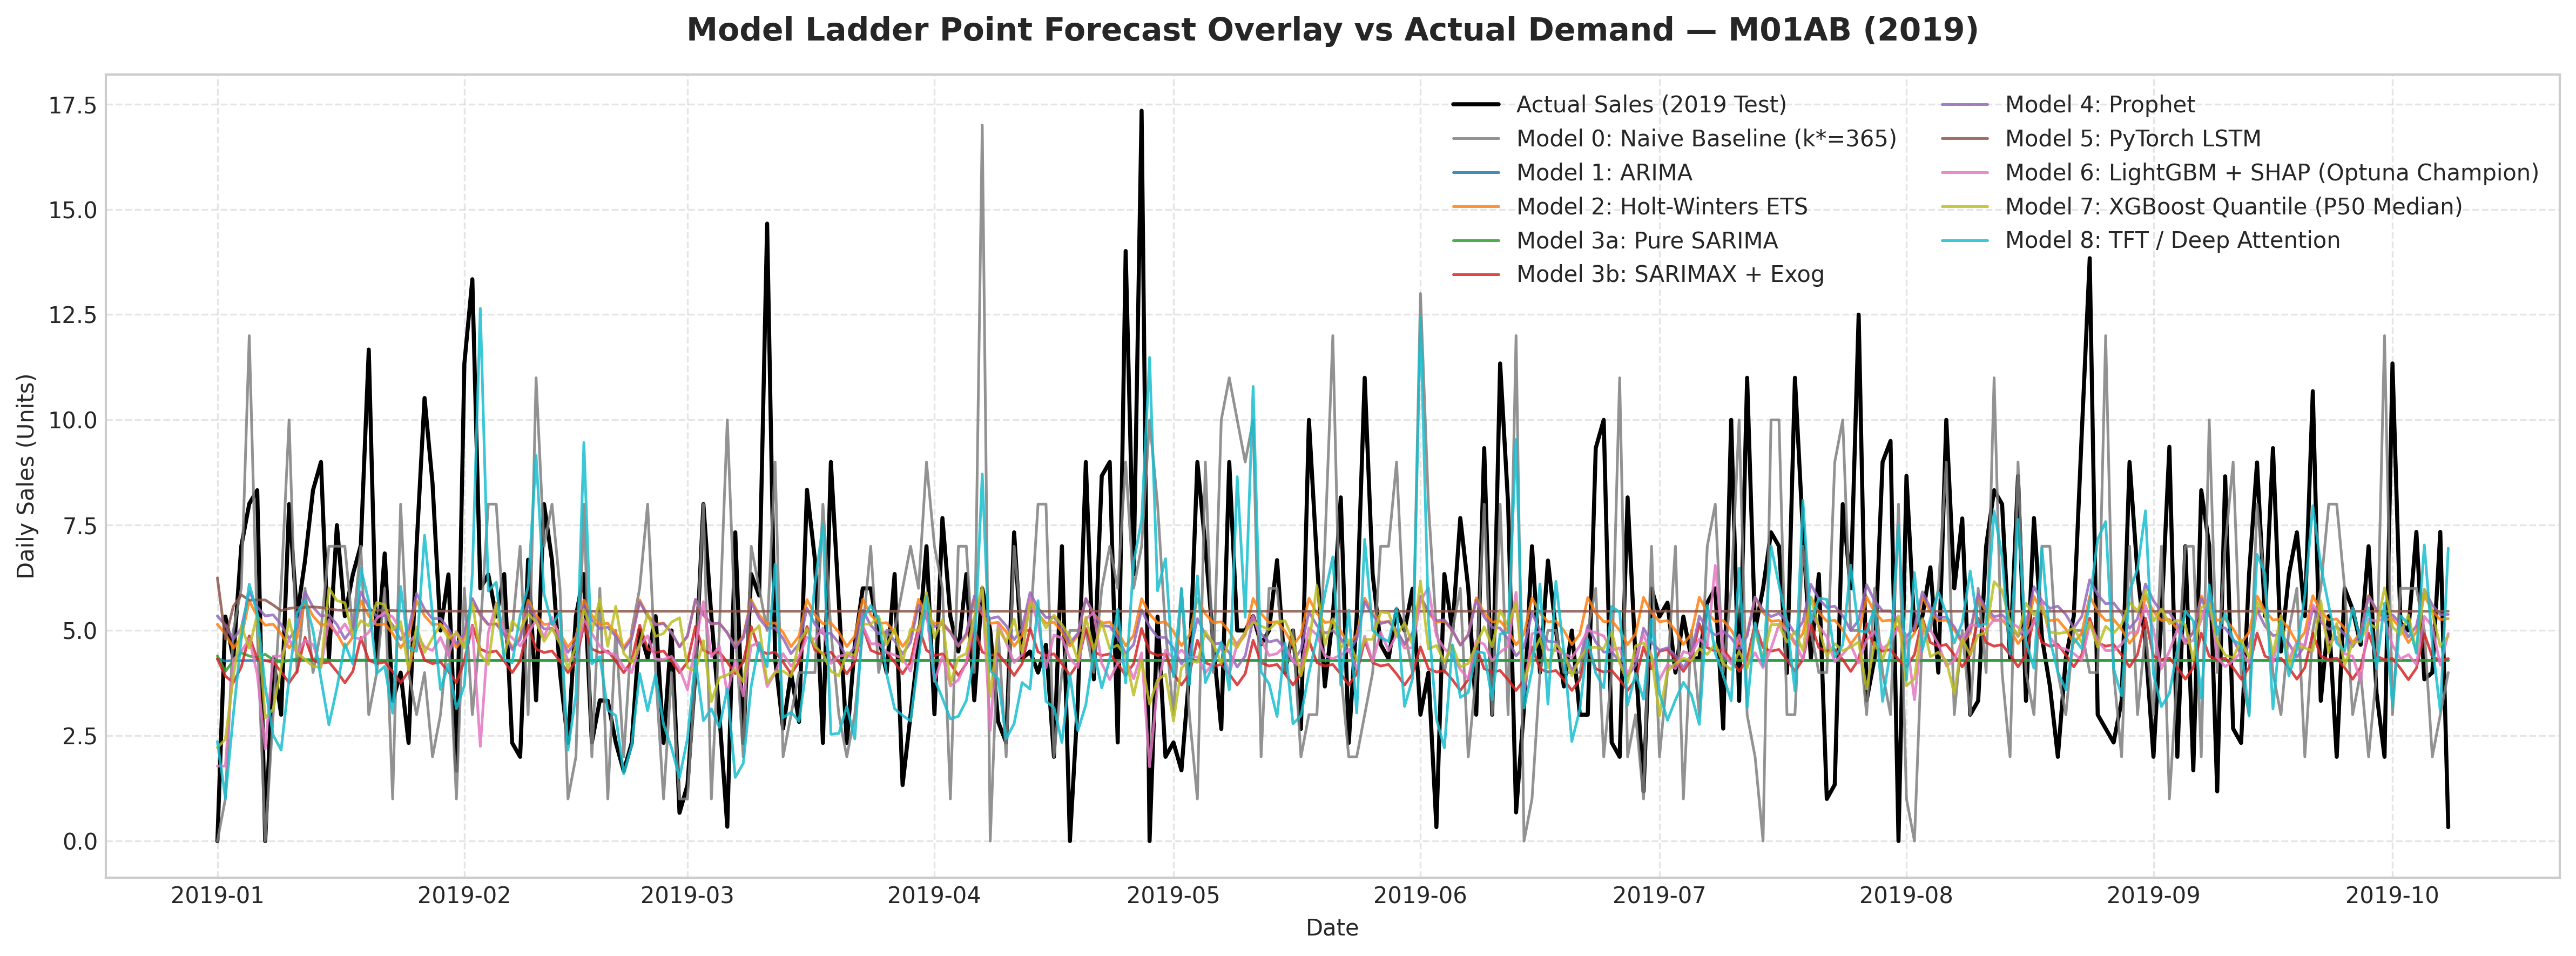

In [4]:
# Render Model Prediction Overlay Chart vs Actual Sales
plt.figure(figsize=(16, 6), dpi=300)
plt.plot(test_series.index, test_series.values, label='Actual Sales (2019 Test)', color='black', linewidth=1.8)

colors = ['#7f7f7f', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#bcbd22', '#17becf']
for idx, (m_name, preds) in enumerate(point_preds.items()):
    plt.plot(test_series.index, preds, label=m_name, linewidth=1.2, alpha=0.85, color=colors[idx % len(colors)])

plt.title(f'Model Ladder Point Forecast Overlay vs Actual Demand — {TARGET_DRUG} (2019)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date')
plt.ylabel('Daily Sales (Units)')
plt.legend(loc='upper right', ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
